In [6]:

# SECTION 0: SETUP & IMPORTS
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# PySpark & SynapseML Imports
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, mean, stddev, expr, when, abs as spark_abs, lit, sum as spark_sum
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType
from pyspark.ml.feature import VectorAssembler

# NOTE: To run SynapseML locally, your SparkSession needs the correct Maven coordinates.
# If you are already running this in Azure Synapse Analytics, this configuration is native.
spark = SparkSession.builder \
    .appName("FinancialOutlierDetection") \
    .config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:1.0.4") \
    .config("spark.jars.repositories", "https://mmlspark.azureedge.net/maven") \
    .config("spark.jars.excludes", "org.scala-lang:scala-reflect,org.apache.spark:spark-tags_2.12,org.scalactic:scalactic_2.12,org.scalatest:scalatest_2.12,com.fasterxml.jackson.core:jackson-databind") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("FINANCIAL DATA QUALITY & OUTLIER DETECTION FRAMEWORK (PySpark Edition)")

FINANCIAL DATA QUALITY & OUTLIER DETECTION FRAMEWORK (PySpark Edition)


26/04/07 13:18:06 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [7]:

# PYSPARK HELPER FUNCTIONS
# -------------------------

def detect_outliers_dq_spark(df, column_name="value", threshold_factor=3):
    """Simple DQ check using mean ± threshold_factor * std in PySpark"""
    stats_df = df.select(
        mean(col(column_name)).alias("mean"),
        stddev(col(column_name)).alias("std")
    ).collect()[0]
    
    mean_val, std_val = stats_df["mean"], stats_df["std"]
    lower_bound = mean_val - (threshold_factor * std_val)
    upper_bound = mean_val + (threshold_factor * std_val)
    
    df_out = df.withColumn("dq_outlier", 
                           when((col(column_name) < lower_bound) | (col(column_name) > upper_bound), 1).otherwise(0))
    return df_out, (lower_bound, upper_bound)

def detect_outliers_iqr_spark(df, column_name="value", multiplier=1.5):
    """IQR method for outlier detection in PySpark"""
    # Calculate approximate quantiles (0.0 relative error for exactness on small data)
    quantiles = df.stat.approxQuantile(column_name, [0.25, 0.75], 0.0)
    q1, q3 = quantiles[0], quantiles[1]
    iqr = q3 - q1
    
    lower_bound = q1 - (multiplier * iqr)
    upper_bound = q3 + (multiplier * iqr)
    
    df_out = df.withColumn("iqr_outlier", 
                           when((col(column_name) < lower_bound) | (col(column_name) > upper_bound), 1).otherwise(0))
    return df_out, (lower_bound, upper_bound)

def detect_outliers_zscore_spark(df, column_name="value", threshold=3):
    """Z-score method for outlier detection in PySpark"""
    stats_df = df.select(
        mean(col(column_name)).alias("mean"),
        stddev(col(column_name)).alias("std")
    ).collect()[0]
    
    mean_val, std_val = stats_df["mean"], stats_df["std"]
    
    df_out = df.withColumn("z_score", spark_abs((col(column_name) - mean_val) / std_val))
    df_out = df_out.withColumn("z_outlier", when(col("z_score") > threshold, 1).otherwise(0))
    return df_out.drop("z_score"), threshold

def detect_outliers_robust_zscore_spark(df, column_name="value", threshold=3.5):
    """Robust Z-score using median and MAD in PySpark"""
    median = df.stat.approxQuantile(column_name, [0.5], 0.0)[0]
    
    # Calculate Absolute Deviation from Median
    df_mad = df.withColumn("abs_dev", spark_abs(col(column_name) - median))
    mad = df_mad.stat.approxQuantile("abs_dev", [0.5], 0.0)[0]
    
    # Avoid division by zero
    mad_safe = mad if mad != 0 else 1e-6
    
    df_out = df.withColumn("robust_z", lit(0.6745) * (col(column_name) - median) / mad_safe)
    df_out = df_out.withColumn("rz_outlier", when(spark_abs(col("robust_z")) > threshold, 1).otherwise(0))
    return df_out.drop("robust_z"), threshold

def create_comparison_plot_from_spark(df, title, figsize=(16, 10)):
    """Convert small Spark DF to Pandas and plot comprehensive comparison"""
    pdf = df.toPandas()
    data = pdf['value'].values
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    # Plot 1, 2, 3: Distributions
    axes[0, 0].hist(data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].set_title('Data Distribution')
    axes[0, 1].boxplot(data, vert=True)
    axes[0, 1].set_title('Box Plot')
    stats.probplot(data, dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title('Q-Q Plot')
    
    # Plot 4: Methods comparison
    methods = ['dq_outlier', 'iqr_outlier', 'z_outlier', 'rz_outlier']
    method_names = ['DQ', 'IQR', 'Z-Score', 'Robust Z']
    outlier_counts = [pdf[m].sum() for m in methods]
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    bars = axes[1, 0].bar(method_names, outlier_counts, color=colors)
    axes[1, 0].set_title('Outliers Detected by Each Method')
    axes[1, 0].tick_params(axis='x', rotation=45)
    
    for bar in bars:
        height = bar.get_height()
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')
    
    # Plot 5: Scatter with outliers
    x_range = np.arange(len(data))
    axes[1, 1].scatter(x_range, data, alpha=0.5, s=30, label='Normal', color='blue')
    
    colors_scatter = ['red', 'orange', 'green', 'purple']
    for i, m in enumerate(methods):
        indices = pdf[pdf[m] == 1].index
        if len(indices) > 0:
            axes[1, 1].scatter(indices, data[indices], alpha=0.8, s=100, marker='x', 
                               label=f'{method_names[i]} ({len(indices)})', color=colors_scatter[i])
            
    axes[1, 1].set_title('Outliers Visualization')
    axes[1, 1].legend(loc='best', fontsize=8)
    
    # Plot 6: Summary Stats
    axes[1, 2].axis('off')
    summary_text = f"""
    STATISTICAL SUMMARY
    {'=' * 35}
    Count: {len(data)}
    Mean: {np.mean(data):.2f}
    Median: {np.median(data):.2f}
    Std Dev: {np.std(data):.2f}
    Skewness: {stats.skew(data):.3f}
    """
    axes[1, 2].text(0.1, 0.9, summary_text, transform=axes[1, 2].transAxes,
                   fontsize=10, verticalalignment='top', fontfamily='monospace',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
    
    plt.tight_layout()
    plt.show()

--- Normal Data ---
+--------------------+
|               value|
+--------------------+
|0.059934283060224657|
| 0.04723471397657631|
| 0.06295377076201385|
|  0.0804605971281605|
|0.045316932505533286|
|0.045317260861016395|
| 0.08158425631014783|
| 0.06534869458305818|
|0.040610512281300956|
|0.060851200871719295|
| 0.04073164614375076|
| 0.04068540492859486|
| 0.05483924543132068|
|0.011734395106844042|
|0.015501643349739344|
| 0.03875424941518055|
|0.029743377593311526|
| 0.05628494665190548|
| 0.03183951848957578|
| 0.02175392597329417|
+--------------------+
only showing top 20 rows

--- Skewed Data ---
+------------------+
|             value|
+------------------+
| 540.2733209186713|
| 251.1673382758245|
|127.68039154564681|
| 411.9085798624325|
|2863.1211226911496|
| 390.3838028814744|
| 731.4528057601519|
|1214.0869768808548|
|451.97449896696236|
|3567.7981382916996|
| 3282.009864541398|
|290.06129499220526|
| 687.6592784638473|
| 357.9304600790468|
| 335.2496763810817|
|37.

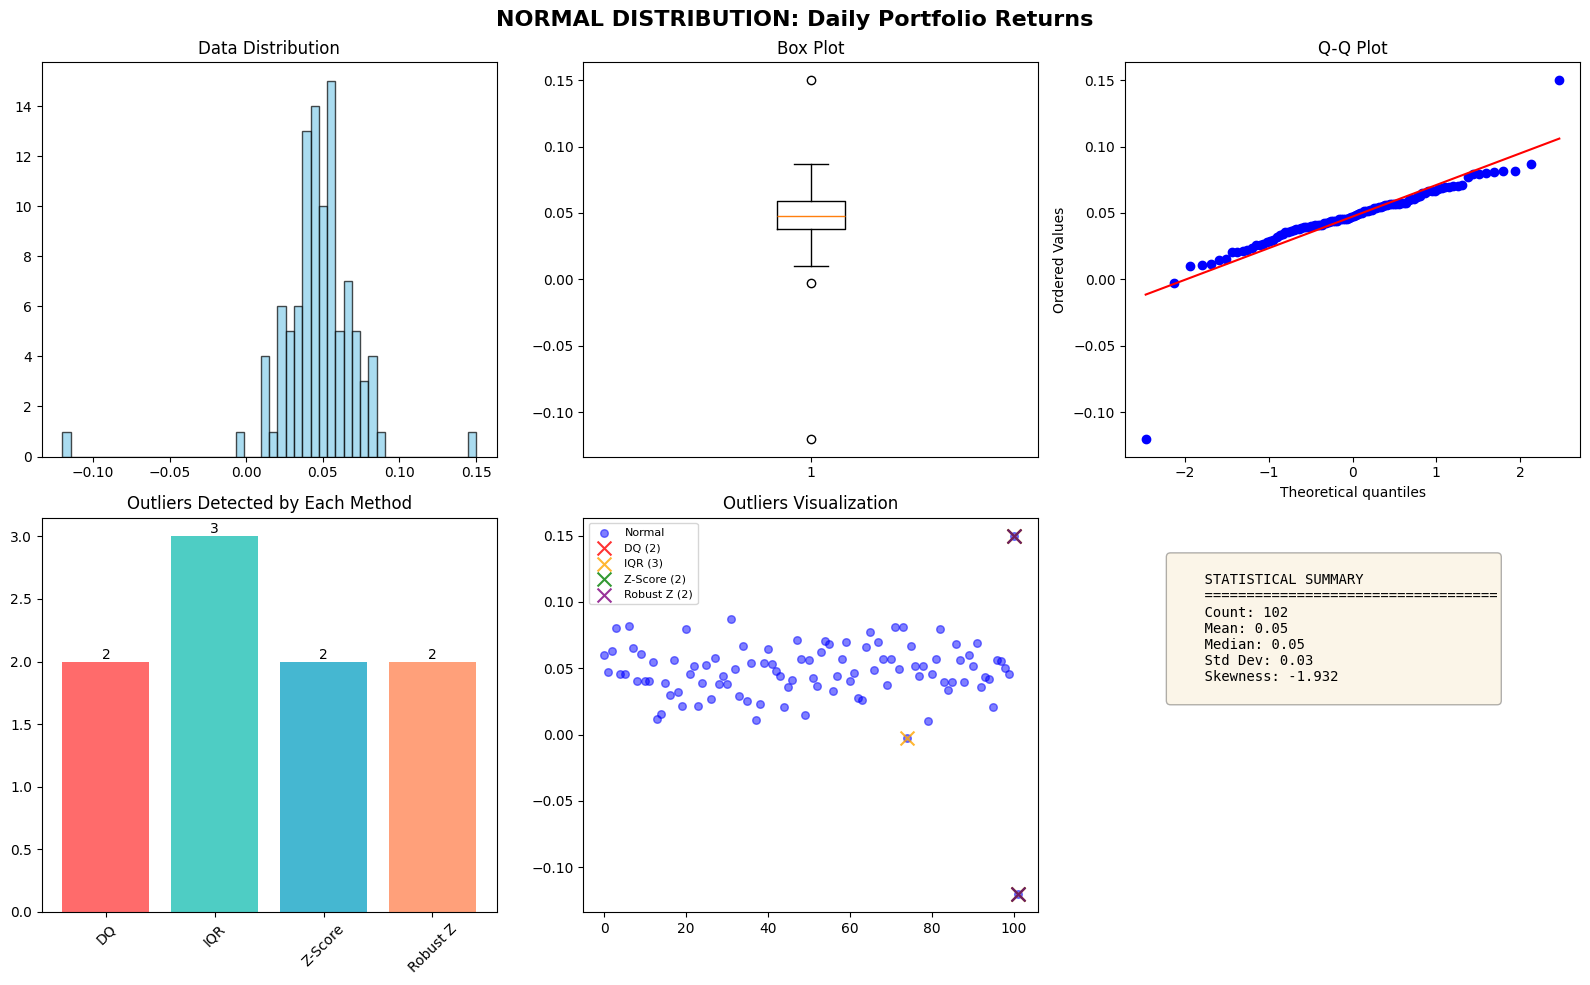


--- Dataset 1.2: SKEWED DISTRIBUTION (Transaction Amounts) ---
DQ Method: 3 outliers
IQR Method: 8 outliers
Z-Score: 3 outliers
Robust Z-Score: 7 outliers


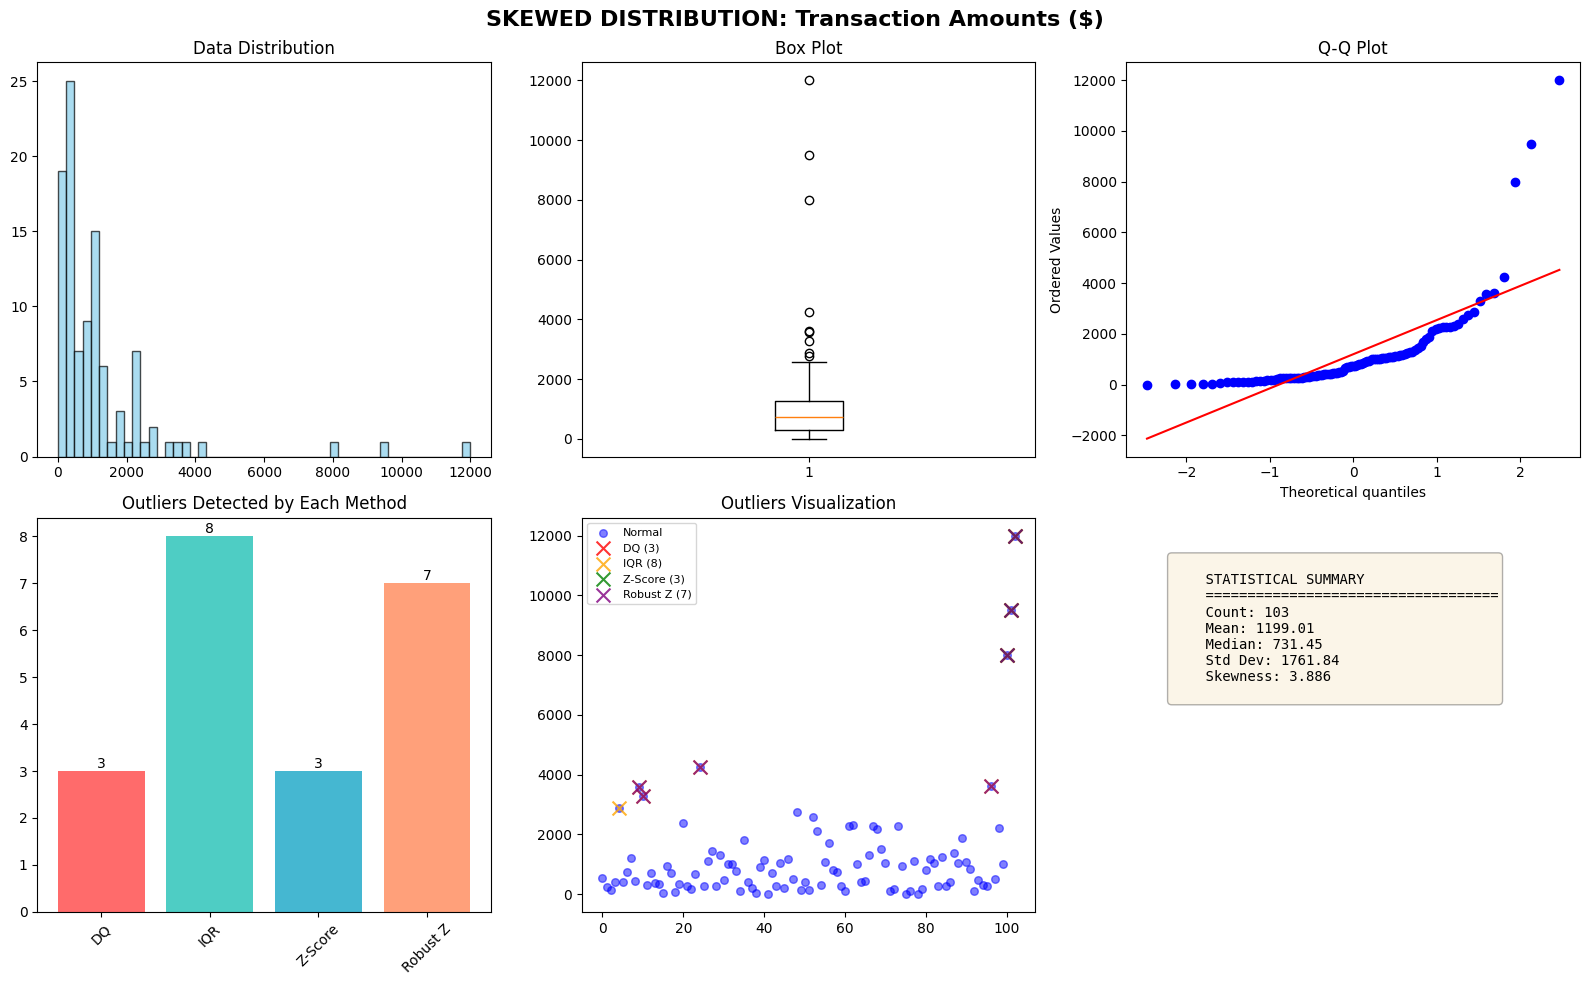

In [8]:
# SECTION 1: EXECUTION
# ---------------------

# We will generate data using NumPy to replicate the exact scenarios, 
# then convert them to PySpark DataFrames for the outlier processing.
np.random.seed(42)

# Dataset 1.1: Normal Distribution (Financial Returns)
normal_data = np.random.normal(loc=0.05, scale=0.02, size=100)
normal_data = np.append(normal_data, [0.15, -0.12])
df_normal = spark.createDataFrame([(float(x),) for x in normal_data], ["value"])

# Dataset 1.2: Skewed Distribution (Transaction Amounts)
skewed_data = np.random.exponential(scale=1000, size=100)
skewed_data = np.append(skewed_data, [8000, 9500, 12000])
df_skewed = spark.createDataFrame([(float(x),) for x in skewed_data], ["value"])


print("--- Normal Data ---")
# Show the last 5 rows to easily see the outliers we appended
# df_normal.tail(5) 
df_normal.show()

print("--- Skewed Data ---")
# df_skewed.tail(5)
df_skewed.show()

# --- PROCESS NORMAL DATA ---
print("\n--- Dataset 1.1: NORMAL DISTRIBUTION (Daily Returns) ---")
df_normal, normal_dq_bounds = detect_outliers_dq_spark(df_normal)
df_normal, normal_iqr_bounds = detect_outliers_iqr_spark(df_normal)
df_normal, normal_z_thresh = detect_outliers_zscore_spark(df_normal)
df_normal, normal_rz_thresh = detect_outliers_robust_zscore_spark(df_normal)

# Show results
normal_results = df_normal.select(
    spark_sum("dq_outlier").alias("DQ"),
    spark_sum("iqr_outlier").alias("IQR"),
    spark_sum("z_outlier").alias("Z-Score"),
    spark_sum("rz_outlier").alias("Robust Z")
).collect()[0]

print(f"DQ Method: {normal_results['DQ']} outliers")
print(f"IQR Method: {normal_results['IQR']} outliers")
print(f"Z-Score: {normal_results['Z-Score']} outliers")
print(f"Robust Z-Score: {normal_results['Robust Z']} outliers")

create_comparison_plot_from_spark(df_normal, "NORMAL DISTRIBUTION: Daily Portfolio Returns")

# --- PROCESS SKEWED DATA ---
print("\n--- Dataset 1.2: SKEWED DISTRIBUTION (Transaction Amounts) ---")
df_skewed, skewed_dq_bounds = detect_outliers_dq_spark(df_skewed)
df_skewed, skewed_iqr_bounds = detect_outliers_iqr_spark(df_skewed)
df_skewed, skewed_z_thresh = detect_outliers_zscore_spark(df_skewed)
df_skewed, skewed_rz_thresh = detect_outliers_robust_zscore_spark(df_skewed)

skewed_results = df_skewed.select(
    spark_sum("dq_outlier").alias("DQ"),
    spark_sum("iqr_outlier").alias("IQR"),
    spark_sum("z_outlier").alias("Z-Score"),
    spark_sum("rz_outlier").alias("Robust Z")
).collect()[0]

print(f"DQ Method: {skewed_results['DQ']} outliers")
print(f"IQR Method: {skewed_results['IQR']} outliers")
print(f"Z-Score: {skewed_results['Z-Score']} outliers")
print(f"Robust Z-Score: {skewed_results['Robust Z']} outliers")

create_comparison_plot_from_spark(df_skewed, "SKEWED DISTRIBUTION: Transaction Amounts ($)")

### SECTION 1: Normal vs Skewed Distributions
**Objective**: Understand when to use IQR vs Z-Score vs Robust Z-Score

#### Dataset 1.1: Normal Distribution (Daily Portfolio Returns)
- **Data**: 100 daily returns with μ=5%, σ=2% + 2 outliers
- **Skewness**: -1.932 (approximately symmetric)
- **Results**:
  - DQ Method: 2 outliers (bounds: -3.20% to 12.66%)
  - IQR Method: 3 outliers
  - Z-Score: 2 outliers
  - Robust Z-Score: 2 outliers

**✓ Key Insight**: For normal distributions, all methods perform similarly. Use Z-Score or DQ for efficiency.

#### Dataset 1.2: Skewed Distribution (Transaction Amounts)
- **Data**: 100 exponentially distributed transactions + 3 fraudulent
- **Skewness**: 3.886 (highly right-skewed)
- **Results**:
  - DQ Method: 3 outliers (bounds: -$4,086 to $6,484)
  - IQR Method: 9 outliers (bounds: -$1,212 to $2,759)
  - Z-Score: 3 outliers
  - Robust Z-Score: 7 outliers

**✓ Key Insight**: For skewed distributions, IQR and Robust Z-Score detect 2-3x more outliers. DQ/Z-Score miss outliers due to inflated mean/std.

**Recommendation**: 
- Normal data → Z-Score (threshold = 3)
- Skewed data → IQR (multiplier = 1.5) or Robust Z-Score (threshold = 3.5)

---

--- Dataset Overview ---


Total Transactions: 100
Normal: 90, Fraudulent: 10


26/04/07 13:18:14 WARN IsolationForest: Observed contamination is 0.12, which is outside the expected range of 0.1 +/- 0.01. If this is acceptable to you, then it is OK to proceed. If there is a very large discrepancy between observed and expected values, then please try retraining the model with an exact threshold calculation (set the contaminationError parameter value to 0.0).



--- SynapseML Isolation Forest Results ---
Total outliers detected: 12
Fraud detected: 6/10 (60%)
False positives: 6


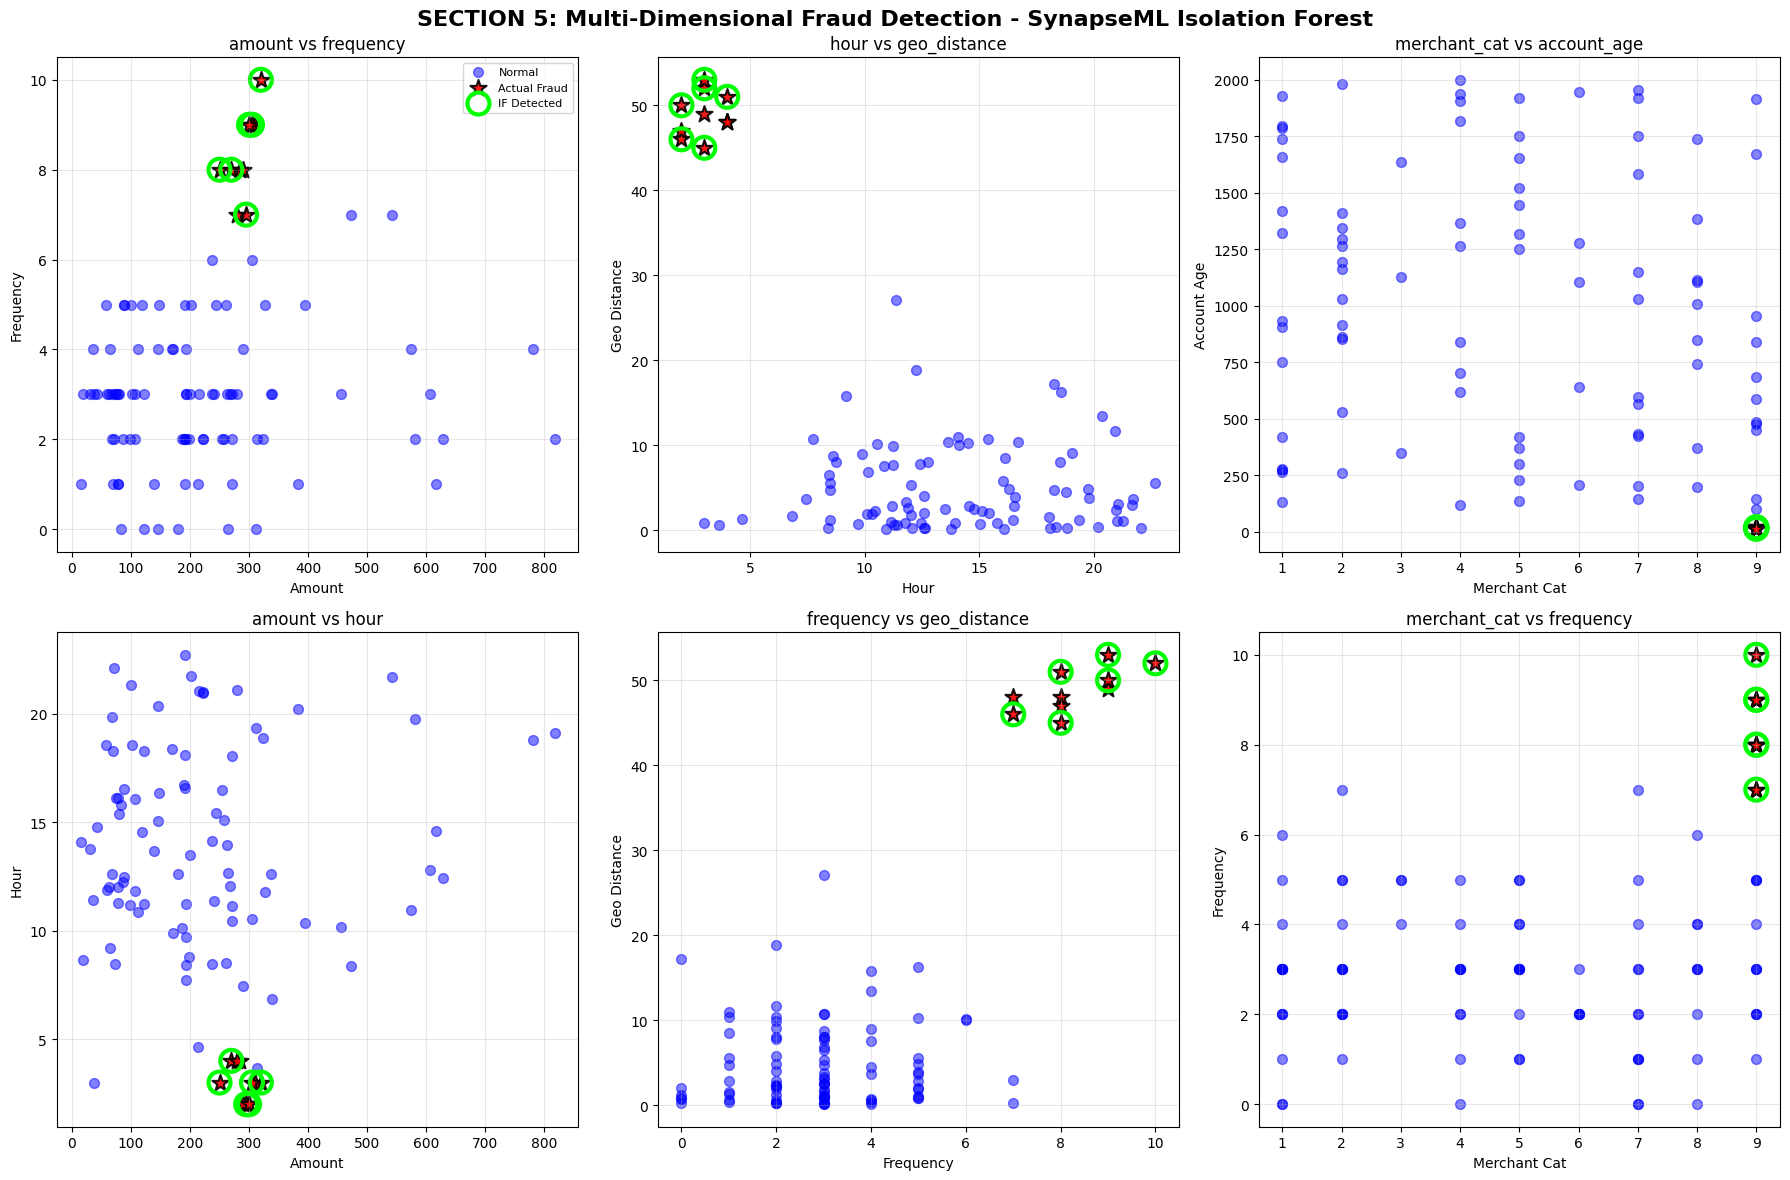

In [9]:

# SECTION 2: SYNAPSE ML ISOLATION FOREST IMPLEMENTATION (Synapse-only)
# ---------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum as spark_sum
from pyspark.ml.feature import VectorAssembler
from synapse.ml.isolationforest import IsolationForest

# Rebuild Spark session with SynapseML package coordinates.
# 1.1.2 is the Python package installed in this kernel.
try:
    spark.stop()
except Exception:
    pass

spark = SparkSession.builder \
    .appName("Section5-SynapseIF") \
    .config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:1.1.2") \
    .config("spark.jars.repositories", "https://mmlspark.azureedge.net/maven") \
    .getOrCreate()
spark.sparkContext.setLogLevel("WARN")

np.random.seed(101)
n_normal = 90
n_fraud = 10

normal_transactions = {
    'amount': np.random.gamma(shape=2, scale=100, size=n_normal),
    'frequency': np.random.poisson(lam=3, size=n_normal),
    'merchant_cat': np.random.randint(1, 10, size=n_normal),
    'hour': np.random.normal(loc=14, scale=4, size=n_normal).clip(0, 23),
    'geo_distance': np.random.exponential(scale=5, size=n_normal),
    'account_age': np.random.uniform(100, 2000, size=n_normal),
    'is_fraud': [0] * n_normal
}

fraud_transactions = {
    'amount': np.array([250, 300, 280, 320, 290, 310, 270, 295, 305, 285]),
    'frequency': np.array([8, 9, 7, 10, 8, 9, 8, 7, 9, 8]),
    'merchant_cat': np.array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9]),
    'hour': np.array([3, 2, 4, 3, 2, 3, 4, 2, 3, 4]),
    'geo_distance': np.array([45, 50, 48, 52, 47, 49, 51, 46, 53, 48]),
    'account_age': np.array([15, 18, 12, 20, 14, 16, 13, 19, 17, 11]),
    'is_fraud': [1] * n_fraud
}

pdf_sec5 = pd.DataFrame(normal_transactions)
pdf_fraud = pd.DataFrame(fraud_transactions)
pdf_combined = pd.concat([pdf_sec5, pdf_fraud]).sample(frac=1, random_state=42).reset_index(drop=True)
df_sec5 = spark.createDataFrame(pdf_combined)

print("--- Dataset Overview ---")
print(f"Total Transactions: {df_sec5.count()}")
print(f"Normal: {n_normal}, Fraudulent: {n_fraud}")

feature_cols = ['amount', 'frequency', 'merchant_cat', 'hour', 'geo_distance', 'account_age']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_df = assembler.transform(df_sec5)

iso_forest = IsolationForest(
    featuresCol="features",
    predictionCol="prediction",
    scoreCol="outlierScore",
    contamination=0.1,
    contaminationError=0.01,
    numEstimators=100,
    maxSamples=100,
    maxFeatures=1.0,
    randomSeed=42
)

model = iso_forest.fit(assembled_df)
predictions = model.transform(assembled_df)

eval_iso = predictions.select(
    spark_sum(when(col("prediction") == 1, 1).otherwise(0)).alias("total_flagged"),
    spark_sum(when((col("prediction") == 1) & (col("is_fraud") == 1), 1).otherwise(0)).alias("true_fraud_caught")
).collect()[0]

total_flagged = eval_iso['total_flagged']
true_fraud_caught = eval_iso['true_fraud_caught']

print("\n--- SynapseML Isolation Forest Results ---")
print(f"Total outliers detected: {total_flagged}")
print(f"Fraud detected: {true_fraud_caught}/{n_fraud} ({(true_fraud_caught/n_fraud)*100:.0f}%)")
print(f"False positives: {total_flagged - true_fraud_caught}")

plot_df = predictions.select(
    "amount", "frequency", "merchant_cat", "hour", "geo_distance",
    "account_age", "is_fraud", "prediction", "outlierScore"
).toPandas()

fig6, axes = plt.subplots(2, 3, figsize=(18, 12))
fig6.suptitle('SECTION 5: Multi-Dimensional Fraud Detection - SynapseML Isolation Forest', fontsize=16, fontweight='bold')

feature_pairs = [
    ('amount', 'frequency'), ('hour', 'geo_distance'), ('merchant_cat', 'account_age'),
    ('amount', 'hour'), ('frequency', 'geo_distance'), ('merchant_cat', 'frequency')
]

for idx, (f1, f2) in enumerate(feature_pairs):
    ax = axes[idx // 3, idx % 3]

    normal_mask = plot_df['is_fraud'] == 0
    ax.scatter(plot_df.loc[normal_mask, f1], plot_df.loc[normal_mask, f2], alpha=0.5, s=50, label='Normal', color='blue')

    fraud_mask = plot_df['is_fraud'] == 1
    ax.scatter(plot_df.loc[fraud_mask, f1], plot_df.loc[fraud_mask, f2], alpha=0.9, s=150, marker='*', label='Actual Fraud', color='red', edgecolor='black', linewidth=1.5)

    iso_mask = plot_df['prediction'] == 1
    detected_fraud_mask = iso_mask & fraud_mask
    ax.scatter(plot_df.loc[detected_fraud_mask, f1], plot_df.loc[detected_fraud_mask, f2], alpha=1, s=250, marker='o', facecolors='none', label='IF Detected', edgecolor='lime', linewidth=3)

    ax.set_xlabel(f1.replace('_', ' ').title())
    ax.set_ylabel(f2.replace('_', ' ').title())
    ax.set_title(f'{f1} vs {f2}')
    if idx == 0:
        ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()